Revised Proposal:


Biological Question:
How do specific craniofacial developmnent pathways (FGF, BMP, Wnt) show gene expression patterns in cranial neural crest-derived soft palate cells across developmnent stages (E13.5, E14.5, E15.5)? 
I aim to focus on a few representative genes from each pathway (for example, FGFR2 for FGF, BMP2, for BMP, and WNT5A for Wnt to observe how their expression changes during normal soft palate development. 

Data:
I will use publicly available single -cell RNA-seq from a Runx2-Twist1 study. 
This dataset includes raw read counts and preprocessed Seurat objects for each stage. 

Analysis Plan:
For each developmental stage, I will: 

    1. Load single-cell RNA-seq data into python using scanpy.
    2. Identify CNC-derived cell populations based on clustering (already annotated in Seurat if pssible). 
    3. Extract expression data for the chosen genes in FGF, BMP, and Wnt pathways. 
    4. Compare expression levels across stages to see developmental trends. 
    5. Generate visualizations for each gene or pathway. 
        -Violin plots to show distribution of gene expression across cells. 
        -Heatmaps to show expression patterns across stages.
        -UMAP plots to visualize where these genes are expressed in the cell clusters. 
        
Tools:
I will use python with: 
    -scanpy for single-cell RNA-seq data analysis
    -pandas and numpy for data manipulation
    -matplotlib and seaborn for visualization 
    

Dataset:
https://www.facebase.org/chaise/record/#1/isa:dataset/RID=1-X280 - TGF-β / RUNX2 

Tools: 
1. pandas
2. numpy
3. matplotlib
4. seaborn
5. scanpy

In [3]:
# import packages 

import scanpy as sc
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

Updated Task/ Workflow Overview 

Goal: Compare cell types and craniofacial pathway gene expression across E13.5, E14.5, and E15.5 soft palate 

1. Import packages- scanpy, pandas, numpy, matplotlib, seaborn
2. Load each sample - 13.5, 14.5 ,15.5
3. Quality control
   - Remove low-quality cells:
         - keep cells less than 200 genes, remove cells move then 2500-3000 genes
     -Remove low-quality genes:
         - keep genes expressed in at least 3 cells
     
4. Normalize and log-transform
   - normalize total counts per cell (target sum = 10,000)
   - log-transfrom to stabilize variance
5. Highly variable genes and scaling
   - identift top 2000 highly variable genes
   - scale data (mean 0, variance 1, max value = 10)
6. Clustering & UMAP
   - Cluster cells
   - Visualize clusters with UMAP
7. Assign broad cell types (marker-based)
   - small, high-confidence marker list:
         - Mesenchymal: Pdgfra, Col1a1, Dlk1
         - Epithelial: Krt8,Krt19. Epcam
         - Endothelial: Pecam1, Cdh5, Kdr
         - Osteogenic : Runx2. Sp7, Alpl
8. Examine genes of interest
   - FGF: Fgf8, Fgfr2
   - BMP: Bmp4, Bmpr1a
   - Wnt: Wnt5a, Fzd7
9. Statistical analysis
   1. Cluster proportions across stages - Chi-square test
   2. Gene expression across stages (within cluster) - One- way ANOVA or Kruskal-Wallis
   3. Optional: Wilcoxon rank-sum for pairwise stage comparisons
10. Visualizations
    -UMAP plots with clusters labeled
    - Stacked barplots showing proportion of each cell type per stage
    - Violin plots showing gene expression for your genes of interest per cluster/stage

In [104]:
# Step 1 

import scanpy as sc
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Step 2 

adata_13 = sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE135control",  
    var_names='gene_symbols', cache=True)

print(adata_13)

AnnData object with n_obs × n_vars = 7381 × 31053
    var: 'gene_ids', 'feature_types'


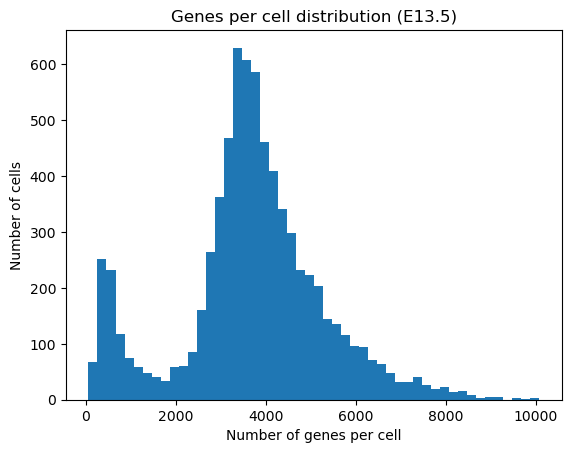

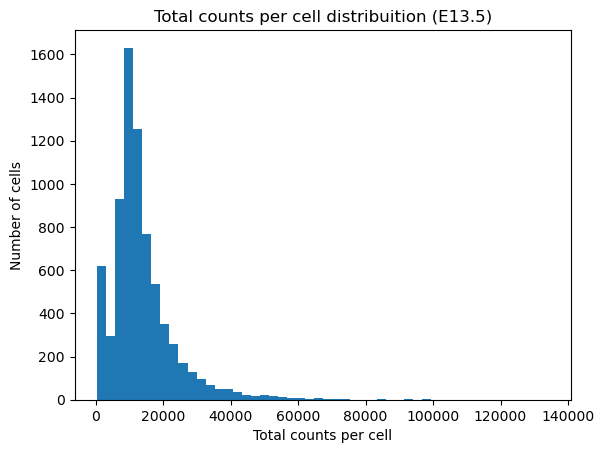

In [105]:
# Step 3

sc.pp.calculate_qc_metrics(adata_13, inplace=True)

#visualize the distribtions 
plt.hist(adata_13.obs['n_genes_by_counts'], bins= 50)
plt.xlabel('Number of genes per cell')
plt.ylabel('Number of cells')
plt.title('Genes per cell distribution (E13.5)')
plt.show()

plt.hist(adata_13.obs['total_counts'], bins=50)
plt.xlabel('Total counts per cell')
plt.ylabel('Number of cells')
plt.title('Total counts per cell distribuition (E13.5)')
plt.show()

In [106]:
#keep cells with 200-2500 genes 
adata_13 = adata_13[adata_13.obs['n_genes_by_counts'] >= 200, :]
adata_13 = adata_13[adata_13.obs['n_genes_by_counts'] >= 2500, :]

#keep genes expressed in at least 3 cells 
adata_13 = adata_13[:, adata_13.var['n_cells_by_counts'] >= 3]

print(adata_13) 

View of AnnData object with n_obs × n_vars = 6225 × 19463
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


In [107]:
#step 4 

#scales each cell to have the same total counts (10,000 is standard)
sc.pp.normalize_total(adata_13, target_sum=1e4)

#log-transform the counts to stabilize variance 
sc.pp.log1p(adata_13)

print(adata_13.X[:5,:5])

/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2 stored elements and shape (5, 5)>
  Coords	Values
  (0, 3)	0.6580442190170288
  (3, 3)	0.6865628957748413


In [108]:
#step 5a - identify highly variable genes

#select the top 2000 genes that vary the most across cells 
sc.pp.highly_variable_genes(adata_13, n_top_genes=2000)

#keep only highly variable genes for downstream analysis 
adata_13 = adata_13[:, adata_13.var['highly_variable']]

#step 5b- scale the data

#centers each gene to mean 0 and variance 1 
#max value=10 prevents extremely high values from skewing results 
sc.pp.scale(adata_13, max_value= 10) 

print(adata_13.X[:5, :5])


#highly variable genes: focus on genes that matter the most for distinguishing cell types 
#scaling: prevents highly expressed genes from dominating clustering 


[[-0.08193497  0.84273143  1.12897132 -0.12744997  3.09564164]
 [-0.08193497  0.48616582 -0.55288736 -0.12744997 -0.67831105]
 [-0.08193497 -0.83819971 -0.55288736 -0.12744997  1.54309558]
 [-0.08193497 -0.83819971 -0.55288736 -0.12744997  0.8172041 ]
 [-0.08193497 -0.83819971 -0.55288736 -0.12744997 -0.67831105]]


/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [109]:
!pip install leidenal



ERROR: Could not find a version that satisfies the requirement leidenal (from versions: none)
ERROR: No matching distribution found for leidenal


[0.06101341 0.04614415 0.0335571  0.0312744  0.02610862 0.0235709
 0.0199055  0.01800215 0.01692708 0.01293622]
leiden
0     743
1     688
2     524
3     484
4     469
5     446
6     422
7     351
9     342
8     342
10    334
11    317
12    218
13    147
14    147
15     87
16     86
17     78
Name: count, dtype: int64


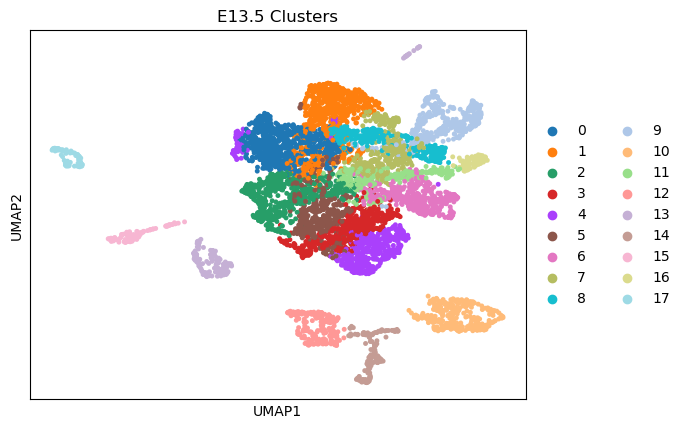

In [110]:
#step 6a- PCA

#PCA reduces the high-dimensional data to a smaller number of components 
sc.tl.pca(adata_13, svd_solver='arpack')

#look at variance explained by the first few PCs
print(adata_13.uns['pca']['variance_ratio'][:10])


#step 6b- compute neighborhood graph 

#defines which cells are neighbors based on PCA
#n_neighbors = 10 (standard for small datasets) 
#n_pcs = 20 (uses first 20 principal components)

sc.pp.neighbors(adata_13, n_neighbors=10, n_pcs=20)

#step 6c- clustering cells
sc.tl.leiden(adata_13, resolution=0.5)

#check the clustrer assignments 
print(adata_13.obs['leiden'].value_counts())

#step 5d UMAP 
sc.tl.umap(adata_13)

#plot UMAP by cluster 
sc.pl.umap(adata_13, color='leiden', size=50, title='E13.5 Clusters') 


In [111]:
#step 7 

#define a smaller marker dictionary for major cell types 
marker_dict = {
    'Epithelial': ['Krt14', 'Krt5'],
    'Mesenchymal': ['Prrx1', 'Twist1'],
    'Endothelial': ['Pecam1', 'Cdh5'],
    'Immune': ['Ptprc'],
    'Schwann cell precursors': ['Sox10', 'Foxd3']
}


#calculate average expression per cluster 

#create a new column with cluster labels as integers 
adata_13.obs['cluster'] = adata_13.obs['leiden'].astype(int)

#creat a dictionary to store cluster -> cell type assignments 
cluster_celltype = {}

# loop through clusters 
for cluster in adata_13.obs['cluster'].unique(): 
    cluster_cells = adata_13[adata_13.obs['cluster'] == cluster]
    avg_exp_per_type = {}
    for cell_type, genes in marker_dict.items():
        genes_present = [g for g in genes if g in cluster_cells.var_names]
        if len(genes_present)  > 0:
            avg_exp = cluster_cells[:, genes_present].X.mean()
            avg_exp_per_type[cell_type] = avg_exp
        else: 
            avg_exp_per_type[cell_type] = 0 
    assigned_type = max(avg_exp_per_type, key=avg_exp_per_type.get)
    cluster_celltype[cluster] = assigned_type

print(cluster_celltype)

{np.int64(6): 'Endothelial', np.int64(7): 'Mesenchymal', np.int64(16): 'Endothelial', np.int64(0): 'Mesenchymal', np.int64(17): 'Endothelial', np.int64(4): 'Mesenchymal', np.int64(5): 'Mesenchymal', np.int64(2): 'Mesenchymal', np.int64(1): 'Mesenchymal', np.int64(3): 'Mesenchymal', np.int64(9): 'Schwann cell precursors', np.int64(11): 'Immune', np.int64(10): 'Epithelial', np.int64(8): 'Endothelial', np.int64(13): 'Endothelial', np.int64(15): 'Immune', np.int64(14): 'Schwann cell precursors', np.int64(12): 'Schwann cell precursors'}


cell_type
Mesenchymal                3705
Endothelial                1075
Schwann cell precursors     707
Immune                      404
Epithelial                  334
Name: count, dtype: int64


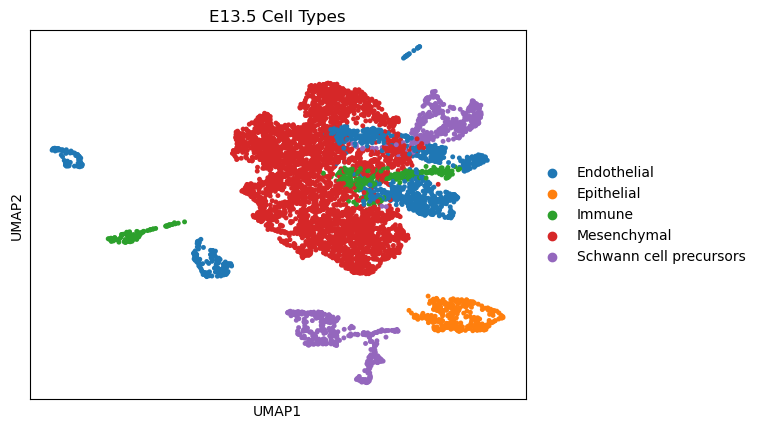

In [112]:
#map cluster number to assigned cell type 
adata_13.obs['cell_type'] = adata_13.obs['cluster'].map(cluster_celltype)

print(adata_13.obs['cell_type'].value_counts())

sc.pl.umap(adata_13, color='cell_type', size=50, title='E13.5 Cell Types') 


In [113]:
#check how many cells have a label
labeled_cells = adata_13.obs['cell_type'].notna().sum()
unlabeled_cells = adata_13.obs['cell_type'].isna().sum()
total_cells = adata_13.n_obs

print(f"Total cells: {total_cells}")
print(f"Labeled cells: {labeled_cells}")
print(f"Unlabeled cells: {unlabeled_cells}")

print(f"Percentage labeled: {labeled_cells/total_cells*100:.2f}%")
print(f"Percentage unlabeled: {unlabeled_cells/total_cells*100:.2f}%")

Total cells: 6225
Labeled cells: 6225
Unlabeled cells: 0
Percentage labeled: 100.00%
Percentage unlabeled: 0.00%


In [114]:
#step 8 
genes_of_interest = ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']

#check which genes exist in the dataset
existing_genes = [g for g in genes_of_interest if g in adata_13.var_names]
print("Genes found in dataset:", existing_genes)

#calculate average expression per cell type 
avg_exp_per_type = adata_13.to_df()[existing_genes].groupby(adata_13.obs['cell_type']).mean()

print(avg_exp_per_type)

Genes found in dataset: ['Fgf8', 'Fgfr2', 'Bmp4', 'Wnt5a']
                             Fgf8     Fgfr2      Bmp4     Wnt5a
cell_type                                                      
Endothelial             -0.094693 -0.330036 -0.212929 -0.015704
Epithelial               1.085956  0.758519 -0.376310 -0.373360
Immune                  -0.058312 -0.504565 -0.187476 -0.219614
Mesenchymal             -0.084426 -0.008447  0.197495  0.110318
Schwann cell precursors -0.002055  0.476076 -0.426299 -0.252365


/var/folders/67/hxtyvk016gs8qbkmcm8skhj00000gn/T/ipykernel_68686/3046839717.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_exp_per_type = adata_13.to_df()[existing_genes].groupby(adata_13.obs['cell_type']).mean()


In [115]:
#step 8a- statistical analysis 
    #One way ANOVA- compare average expression of a gene across multiple cell types 
    # chi-sqaured test - compare porportions of cells expressing a gene (expressed vs not expressed) across cell types 

from scipy.stats import f_oneway 

#create a list of arrays, each array is the expression of Fgfr8 in one cell type 
expr_lists = [adata_13[adata_13.obs['cell_type'] == ct][:, 'Fgf8'].X.flatten() for ct in adata_13.obs['cell_type'].unique() if 'Fgf8' in adata_13.var_names]


#ANOVA
anova_result = f_oneway(*expr_lists)
print("One-way ANOVA result for Fgf8:", anova_result)

One-way ANOVA result for Fgf8: F_onewayResult(statistic=np.float64(190.42381560464096), pvalue=np.float64(3.173884802571735e-154))


Sample E14.5

In [116]:

adata_14 = sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE145control",  
    var_names='gene_symbols', cache=True)

print(adata_14)

AnnData object with n_obs × n_vars = 6190 × 31053
    var: 'gene_ids', 'feature_types'


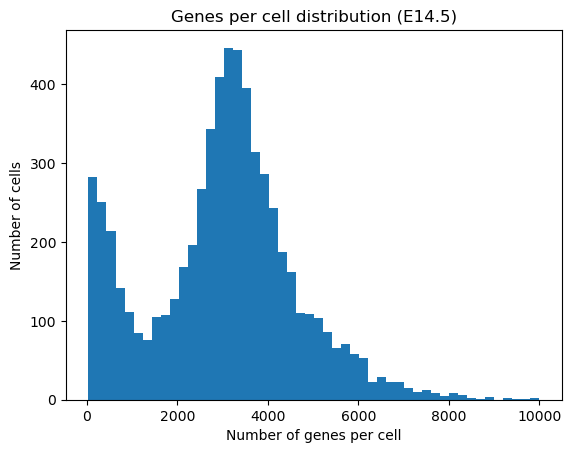

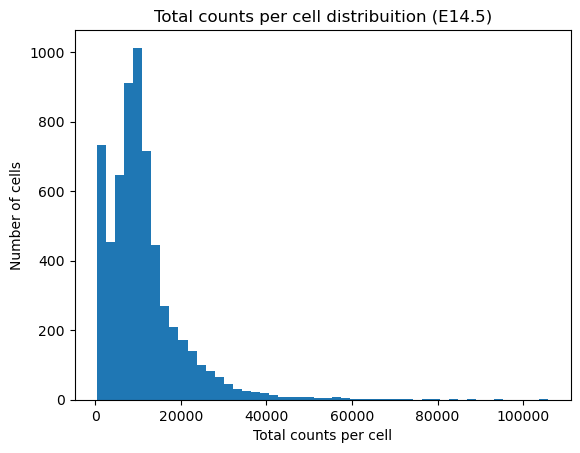

In [117]:
# Step 3

sc.pp.calculate_qc_metrics(adata_14, inplace=True)

#visualize the distribtions 
plt.hist(adata_14.obs['n_genes_by_counts'], bins= 50)
plt.xlabel('Number of genes per cell')
plt.ylabel('Number of cells')
plt.title('Genes per cell distribution (E14.5)')
plt.show()

plt.hist(adata_14.obs['total_counts'], bins=50)
plt.xlabel('Total counts per cell')
plt.ylabel('Number of cells')
plt.title('Total counts per cell distribuition (E14.5)')
plt.show()

In [118]:
#keep cells with 200-2500 genes 
adata_14 = adata_14[adata_14.obs['n_genes_by_counts'] >= 200, :]
adata_14 = adata_14[adata_14.obs['n_genes_by_counts'] >= 2500, :]

#keep genes expressed in at least 3 cells 
adata_14 = adata_14[:, adata_14.var['n_cells_by_counts'] >= 3]

print(adata_14) 

View of AnnData object with n_obs × n_vars = 4215 × 19583
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


In [119]:
#step 4 

#scales each cell to have the same total counts (10,000 is standard)
sc.pp.normalize_total(adata_14, target_sum=1e4)

#log-transform the counts to stabilize variance 
sc.pp.log1p(adata_14)

print(adata_14.X[:5,:5])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 0 stored elements and shape (5, 5)>


/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [120]:
#step 5a - identify highly variable genes

#select the top 2000 genes that vary the most across cells 
sc.pp.highly_variable_genes(adata_14, n_top_genes=2000)

#keep only highly variable genes for downstream analysis 
adata_14 = adata_14[:, adata_14.var['highly_variable']]

#step 5b- scale the data

#centers each gene to mean 0 and variance 1 
#max value=10 prevents extremely high values from skewing results 
sc.pp.scale(adata_14, max_value= 10) 

print(adata_14.X[:5, :5])


#highly variable genes: focus on genes that matter the most for distinguishing cell types 
#scaling: prevents highly expressed genes from dominating clustering 


[[-0.09073536 -0.13581895 -0.11118977 -0.07934702 -0.66971031]
 [-0.09073536 -0.13581895 -0.11118977 -0.07934702  0.5834952 ]
 [-0.09073536 -0.13581895  5.31900233 -0.07934702  0.41512641]
 [-0.09073536 -0.13581895 -0.11118977 -0.07934702 -0.66971031]
 [-0.09073536 -0.13581895 -0.11118977 -0.07934702  1.21113087]]


/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


[0.05829225 0.05352436 0.03575286 0.02731722 0.02257478 0.02045906
 0.01925227 0.01331957 0.01246167 0.01177223]
leiden
0     503
1     488
2     459
3     395
4     336
5     309
6     305
7     304
8     272
9     134
10    131
11    109
12    101
13     98
14     92
15     61
16     55
17     44
18     19
Name: count, dtype: int64


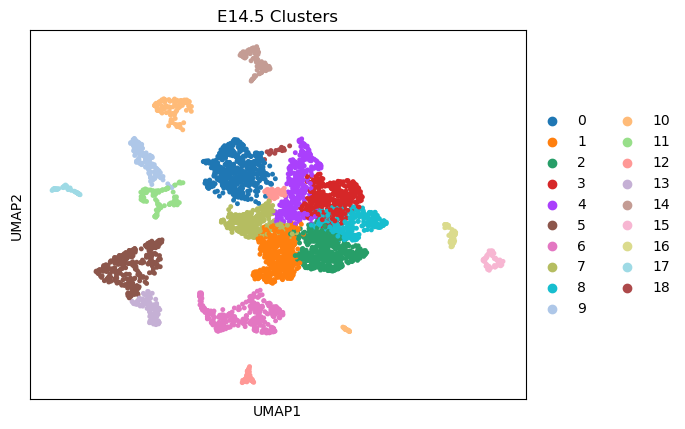

In [121]:
#step 6a- PCA

#PCA reduces the high-dimensional data to a smaller number of components 
sc.tl.pca(adata_14, svd_solver='arpack')

#look at variance explained by the first few PCs
print(adata_14.uns['pca']['variance_ratio'][:10])


#step 6b- compute neighborhood graph 

#defines which cells are neighbors based on PCA
#n_neighbors = 10 (standard for small datasets) 
#n_pcs = 20 (uses first 20 principal components)

sc.pp.neighbors(adata_14, n_neighbors=10, n_pcs=20)

#step 6c- clustering cells
sc.tl.leiden(adata_14, resolution=0.5)

#check the clustrer assignments 
print(adata_14.obs['leiden'].value_counts())

#step 5d UMAP 
sc.tl.umap(adata_14)

#plot UMAP by cluster 
sc.pl.umap(adata_14, color='leiden', size=50, title='E14.5 Clusters') 


In [122]:
#step 7 

#define a smaller marker dictionary for major cell types 
marker_dict = {
    'Epithelial': ['Krt14', 'Krt5'],
    'Mesenchymal': ['Prrx1', 'Twist1'],
    'Endothelial': ['Pecam1', 'Cdh5'],
    'Immune': ['Ptprc'],
    'Schwann cell precursors': ['Sox10', 'Foxd3']
}


#calculate average expression per cluster 

#create a new column with cluster labels as integers 
adata_14.obs['cluster'] = adata_14.obs['leiden'].astype(int)

#creat a dictionary to store cluster -> cell type assignments 
cluster_celltype = {}

# loop through clusters 
for cluster in adata_14.obs['cluster'].unique(): 
    cluster_cells = adata_14[adata_14.obs['cluster'] == cluster]
    avg_exp_per_type = {}
    for cell_type, genes in marker_dict.items():
        genes_present = [g for g in genes if g in cluster_cells.var_names]
        if len(genes_present)  > 0:
            avg_exp = cluster_cells[:, genes_present].X.mean()
            avg_exp_per_type[cell_type] = avg_exp
        else: 
            avg_exp_per_type[cell_type] = 0 
    assigned_type = max(avg_exp_per_type, key=avg_exp_per_type.get)
    cluster_celltype[cluster] = assigned_type

print(cluster_celltype)

{np.int64(2): 'Mesenchymal', np.int64(4): 'Endothelial', np.int64(8): 'Mesenchymal', np.int64(1): 'Mesenchymal', np.int64(6): 'Epithelial', np.int64(3): 'Schwann cell precursors', np.int64(14): 'Immune', np.int64(11): 'Schwann cell precursors', np.int64(12): 'Schwann cell precursors', np.int64(7): 'Mesenchymal', np.int64(0): 'Mesenchymal', np.int64(5): 'Schwann cell precursors', np.int64(10): 'Schwann cell precursors', np.int64(9): 'Schwann cell precursors', np.int64(17): 'Schwann cell precursors', np.int64(13): 'Schwann cell precursors', np.int64(15): 'Endothelial', np.int64(16): 'Schwann cell precursors', np.int64(18): 'Endothelial'}


cell_type
Mesenchymal                2026
Schwann cell precursors    1376
Endothelial                 416
Epithelial                  305
Immune                       92
Name: count, dtype: int64


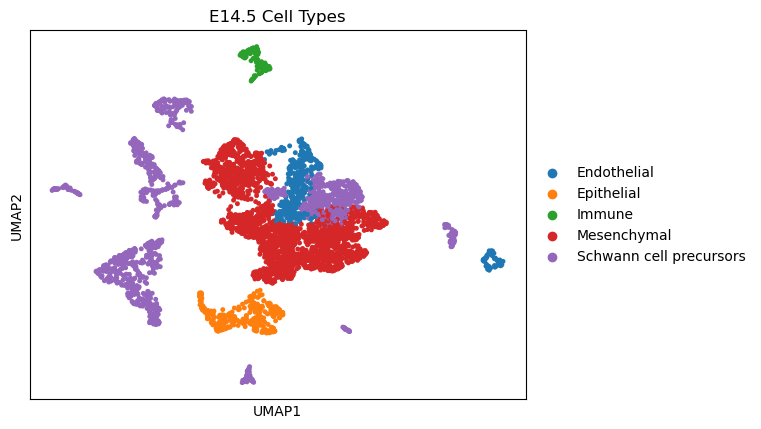

In [123]:
#map cluster number to assigned cell type 
adata_14.obs['cell_type'] = adata_14.obs['cluster'].map(cluster_celltype)

print(adata_14.obs['cell_type'].value_counts())

sc.pl.umap(adata_14, color='cell_type', size=50, title='E14.5 Cell Types') 

In [124]:
#check how many cells have a label
labeled_cells = adata_14.obs['cell_type'].notna().sum()
unlabeled_cells = adata_14.obs['cell_type'].isna().sum()
total_cells = adata_14.n_obs

print(f"Total cells: {total_cells}")
print(f"Labeled cells: {labeled_cells}")
print(f"Unlabeled cells: {unlabeled_cells}")

print(f"Percentage labeled: {labeled_cells/total_cells*100:.2f}%")
print(f"Percentage unlabeled: {unlabeled_cells/total_cells*100:.2f}%")

Total cells: 4215
Labeled cells: 4215
Unlabeled cells: 0
Percentage labeled: 100.00%
Percentage unlabeled: 0.00%


In [125]:
#step 8 
genes_of_interest = ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']

#check which genes exist in the dataset
existing_genes = [g for g in genes_of_interest if g in adata_14.var_names]
print("Genes found in dataset:", existing_genes)

#calculate average expression per cell type 
avg_exp_per_type = adata_14.to_df()[existing_genes].groupby(adata_14.obs['cell_type']).mean()

print(avg_exp_per_type)

Genes found in dataset: ['Fgf8', 'Bmp4', 'Wnt5a']
                             Fgf8      Bmp4     Wnt5a
cell_type                                            
Endothelial             -0.102649 -0.050116 -0.259878
Epithelial              -0.061719 -0.341024 -0.452414
Immune                  -0.112117 -0.600875 -0.627741
Mesenchymal             -0.106948  0.320605  0.215264
Schwann cell precursors  0.177611 -0.341137 -0.096132


/var/folders/67/hxtyvk016gs8qbkmcm8skhj00000gn/T/ipykernel_68686/1102323406.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_exp_per_type = adata_14.to_df()[existing_genes].groupby(adata_14.obs['cell_type']).mean()


Sample E15.5

AnnData object with n_obs × n_vars = 6899 × 31053
    var: 'gene_ids', 'feature_types'


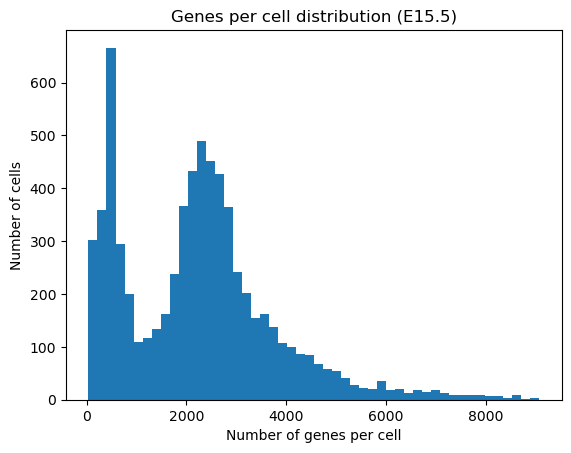

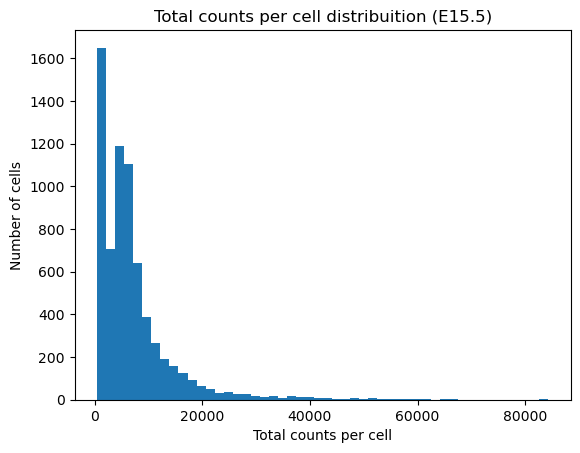

View of AnnData object with n_obs × n_vars = 2754 × 19187
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1 stored elements and shape (5, 5)>
  Coords	Values
  (4, 3)	1.1292308568954468


/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


[[-0.10413641 -0.02921064 -0.16166699 -0.29972826 -0.62461338]
 [-0.10413641 -0.02921064 -0.16166699 -0.29972826  1.55780073]
 [-0.10413641 -0.02921064 -0.16166699 -0.29972826 -0.62461338]
 [-0.10413641 -0.02921064 -0.16166699 -0.29972826 -0.62461338]
 [-0.10413641 -0.02921064 -0.16166699 -0.29972826 -0.62461338]]
[0.14787098 0.06641104 0.03539276 0.02886816 0.02328379 0.02220424
 0.01338656 0.01324397 0.01143793 0.01101481]
leiden
0     331
1     308
2     303
3     273
4     236
5     233
6     215
7     203
8     134
9      91
10     88
11     76
12     65
13     64
14     50
15     48
16     14
17     13
18      9
Name: count, dtype: int64


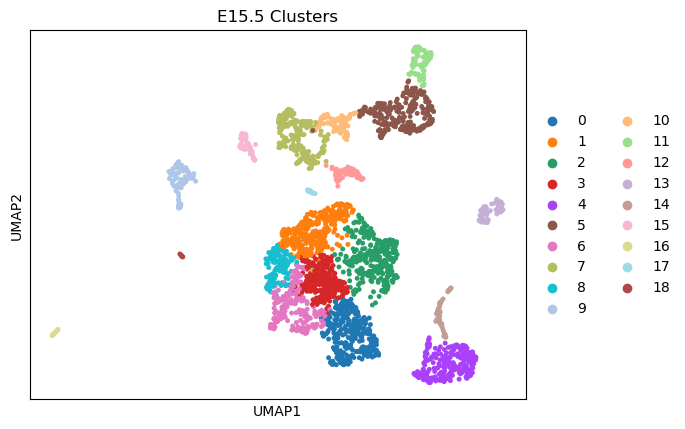

{np.int64(6): 'Mesenchymal', np.int64(3): 'Mesenchymal', np.int64(8): 'Mesenchymal', np.int64(2): 'Mesenchymal', np.int64(11): 'Epithelial', np.int64(7): 'Epithelial', np.int64(18): 'Endothelial', np.int64(1): 'Mesenchymal', np.int64(4): 'Schwann cell precursors', np.int64(10): 'Epithelial', np.int64(16): 'Immune', np.int64(5): 'Epithelial', np.int64(0): 'Mesenchymal', np.int64(9): 'Immune', np.int64(13): 'Endothelial', np.int64(12): 'Endothelial', np.int64(15): 'Schwann cell precursors', np.int64(14): 'Schwann cell precursors', np.int64(17): 'Mesenchymal'}
cell_type
Mesenchymal                1577
Epithelial                  600
Schwann cell precursors     334
Endothelial                 138
Immune                      105
Name: count, dtype: int64


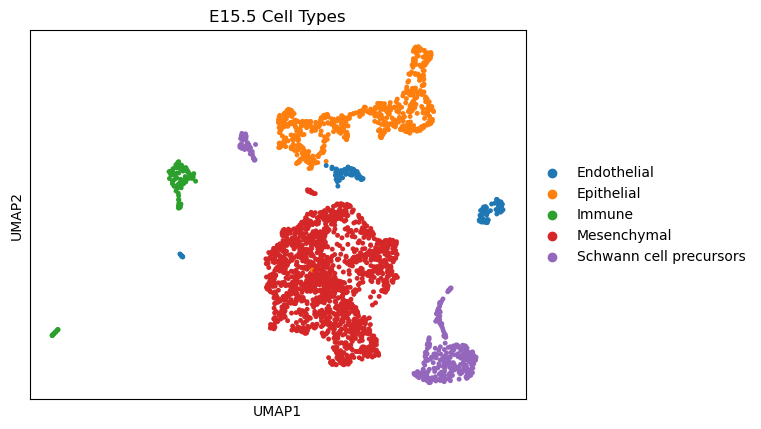

Total cells: 2754
Labeled cells: 2754
Unlabeled cells: 0
Percentage labeled: 100.00%
Percentage unlabeled: 0.00%
Genes found in dataset: ['Bmp4', 'Wnt5a']
                             Bmp4     Wnt5a
cell_type                                  
Endothelial              0.032058 -0.344920
Epithelial              -0.416992 -0.433659
Immune                  -0.599922 -0.616813
Mesenchymal              0.301871  0.347110
Schwann cell precursors -0.500864 -0.523451


/var/folders/67/hxtyvk016gs8qbkmcm8skhj00000gn/T/ipykernel_68686/83576081.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_exp_per_type = adata_15.to_df()[existing_genes].groupby(adata_15.obs['cell_type']).mean()


In [126]:

adata_15 = sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE155control",  
    var_names='gene_symbols', cache=True)

print(adata_15)

# Step 3

sc.pp.calculate_qc_metrics(adata_15, inplace=True)

#visualize the distribtions 
plt.hist(adata_15.obs['n_genes_by_counts'], bins= 50)
plt.xlabel('Number of genes per cell')
plt.ylabel('Number of cells')
plt.title('Genes per cell distribution (E15.5)')
plt.show()

plt.hist(adata_15.obs['total_counts'], bins=50)
plt.xlabel('Total counts per cell')
plt.ylabel('Number of cells')
plt.title('Total counts per cell distribuition (E15.5)')
plt.show()

#keep cells with 200-2500 genes 
adata_15 = adata_15[adata_15.obs['n_genes_by_counts'] >= 200, :]
adata_15 = adata_15[adata_15.obs['n_genes_by_counts'] >= 2500, :]

#keep genes expressed in at least 3 cells 
adata_15 = adata_15[:, adata_15.var['n_cells_by_counts'] >= 3]

print(adata_15) 


#step 4 

#scales each cell to have the same total counts (10,000 is standard)
sc.pp.normalize_total(adata_15, target_sum=1e4)

#log-transform the counts to stabilize variance 
sc.pp.log1p(adata_15)

print(adata_15.X[:5,:5])

#step 5a - identify highly variable genes

#select the top 2000 genes that vary the most across cells 
sc.pp.highly_variable_genes(adata_15, n_top_genes=2000)

#keep only highly variable genes for downstream analysis 
adata_15 = adata_15[:, adata_15.var['highly_variable']]

#step 5b- scale the data

#centers each gene to mean 0 and variance 1 
#max value=10 prevents extremely high values from skewing results 
sc.pp.scale(adata_15, max_value= 10) 

print(adata_15.X[:5, :5])


#highly variable genes: focus on genes that matter the most for distinguishing cell types 
#scaling: prevents highly expressed genes from dominating clustering 


#step 6a- PCA

#PCA reduces the high-dimensional data to a smaller number of components 
sc.tl.pca(adata_15, svd_solver='arpack')

#look at variance explained by the first few PCs
print(adata_15.uns['pca']['variance_ratio'][:10])


#step 6b- compute neighborhood graph 

#defines which cells are neighbors based on PCA
#n_neighbors = 10 (standard for small datasets) 
#n_pcs = 20 (uses first 20 principal components)

sc.pp.neighbors(adata_15, n_neighbors=10, n_pcs=20)

#step 6c- clustering cells
sc.tl.leiden(adata_15, resolution=0.5)

#check the clustrer assignments 
print(adata_15.obs['leiden'].value_counts())

#step 5d UMAP 
sc.tl.umap(adata_15)

#plot UMAP by cluster 
sc.pl.umap(adata_15, color='leiden', size=50, title='E15.5 Clusters') 


#step 7 

#define a smaller marker dictionary for major cell types 
marker_dict = {
    'Epithelial': ['Krt14', 'Krt5'],
    'Mesenchymal': ['Prrx1', 'Twist1'],
    'Endothelial': ['Pecam1', 'Cdh5'],
    'Immune': ['Ptprc'],
    'Schwann cell precursors': ['Sox10', 'Foxd3']
}


#calculate average expression per cluster 

#create a new column with cluster labels as integers 
adata_15.obs['cluster'] = adata_15.obs['leiden'].astype(int)

#creat a dictionary to store cluster -> cell type assignments 
cluster_celltype = {}

# loop through clusters 
for cluster in adata_15.obs['cluster'].unique(): 
    cluster_cells = adata_15[adata_15.obs['cluster'] == cluster]
    avg_exp_per_type = {}
    for cell_type, genes in marker_dict.items():
        genes_present = [g for g in genes if g in cluster_cells.var_names]
        if len(genes_present)  > 0:
            avg_exp = cluster_cells[:, genes_present].X.mean()
            avg_exp_per_type[cell_type] = avg_exp
        else: 
            avg_exp_per_type[cell_type] = 0 
    assigned_type = max(avg_exp_per_type, key=avg_exp_per_type.get)
    cluster_celltype[cluster] = assigned_type

print(cluster_celltype)


#map cluster number to assigned cell type 
adata_15.obs['cell_type'] = adata_15.obs['cluster'].map(cluster_celltype)

print(adata_15.obs['cell_type'].value_counts())

sc.pl.umap(adata_15, color='cell_type', size=50, title='E15.5 Cell Types') 


#check how many cells have a label
labeled_cells = adata_15.obs['cell_type'].notna().sum()
unlabeled_cells = adata_15.obs['cell_type'].isna().sum()
total_cells = adata_15.n_obs

print(f"Total cells: {total_cells}")
print(f"Labeled cells: {labeled_cells}")
print(f"Unlabeled cells: {unlabeled_cells}")

print(f"Percentage labeled: {labeled_cells/total_cells*100:.2f}%")
print(f"Percentage unlabeled: {unlabeled_cells/total_cells*100:.2f}%")


#step 8 
genes_of_interest = ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']

#check which genes exist in the dataset
existing_genes = [g for g in genes_of_interest if g in adata_15.var_names]
print("Genes found in dataset:", existing_genes)

#calculate average expression per cell type 
avg_exp_per_type = adata_15.to_df()[existing_genes].groupby(adata_15.obs['cell_type']).mean()

print(avg_exp_per_type)


In [127]:
#Cluster proportions across stages (Chi-squared test) 


#Goal to see if the composition of cell type changes across stages 

#1. count the number of cells in each cluster (cell type) per stage
#2. create a contingency table (rows = stages, columns = cell types)
#3. apply chi-squared test to see if cell type proportions are significantly different across stages 



from scipy.stats import chi2_contingency 

counts_E13 = adata_13.obs['cell_type'].value_counts()
counts_E14 = adata_14.obs['cell_type'].value_counts()
counts_E15 = adata_15.obs['cell_type'].value_counts()

#combine into a dataframe 
cluster_table = pd.DataFrame([counts_E13, counts_E14, counts_E15], 
                             index=['E13.5', 'E14.5', 'E15.5']).fillna(0)
print(cluster_table)

#chi-squared test
chi2, p, dof, expected = chi2_contingency(cluster_table)
print(f"Chi-squared: {chi2:.2f}, p-value: {p:.4f}")

cell_type  Mesenchymal  Endothelial  Schwann cell precursors  Immune  \
E13.5             3705         1075                      707     404   
E14.5             2026          416                     1376      92   
E15.5             1577          138                      334     105   

cell_type  Epithelial  
E13.5             334  
E14.5             305  
E15.5             600  
Chi-squared: 1704.86, p-value: 0.0000


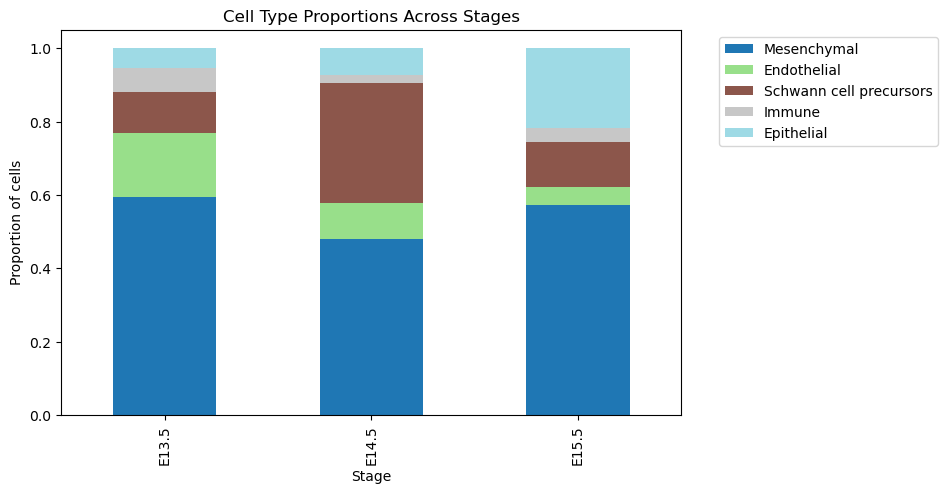

In [128]:
cluster_table_norm = cluster_table.div(cluster_table.sum(axis=1), axis=0)
cluster_table_norm.plot(kind='bar', stacked=True, figsize=(8,5), colormap='tab20')
plt.ylabel("Proportion of cells")
plt.xlabel("Stage")
plt.title("Cell Type Proportions Across Stages")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

1) cells 2) aggregate counts per (cluster x stage) 3) pseudo-bulk count matrix 4) DESeq2 differential expression 

In [ ]:
#DeSeq2 

%pip install pydeseq2

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats 
from pydeseq2.default_inference import DefaultInference 

In [129]:
#load each stage (raw 10x counts) 

adata_13 = sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE135control",  
    var_names='gene_symbols', cache=True)

adata_13.var_names_make_unique()
adata_13.obs["stage"] = "13.5" 

print(adata_13)


adata_14= sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE145control",  
    var_names='gene_symbols', cache=True)

adata_14.var_names_make_unique()
adata_14.obs["stage"] = "14.5" 

print(adata_14)

adata_15 = sc.read_10x_mtx("/Users/aminatafofana/Downloads/SeuratfilesE155control",  
    var_names='gene_symbols', cache=True)

adata_15.var_names_make_unique()
adata_15.obs["stage"] = "15.5" 

print(adata_15)

AnnData object with n_obs × n_vars = 7381 × 31053
    obs: 'stage'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 6190 × 31053
    obs: 'stage'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 6899 × 31053
    obs: 'stage'
    var: 'gene_ids', 'feature_types'


In [153]:
import numpy as np
import scipy.sparse as sp

for ad in [adata_13, adata_14, adata_15]:
    # create counts layer if missing
    if "counts" not in ad.layers:
        ad.layers["counts"] = ad.X.copy()

    # DESeq2 wants integers
    X = ad.layers["counts"]
    if sp.issparse(X):
        ad.layers["counts"] = X.tocsr().copy()
        ad.layers["counts"].data = np.rint(ad.layers["counts"].data).astype(np.int64)
    else:
        ad.layers["counts"] = np.rint(X).astype(np.int64)


In [154]:
for name, ad in [("13.5", adata_13), ("14.5", adata_14), ("15.5", adata_15)]:
    print("\nStage:", name)
    print("has counts layer?", "counts" in ad.layers)
    print("has cell_type?", "cell_type" in ad.obs.columns)
    print("obs cols:", ad.obs.columns.tolist())





Stage: 13.5
has counts layer? True
has cell_type? True
obs cols: ['stage', 'leiden', 'cell_type', 'Mesenchymal_score', 'Epithelial_score', 'Endothelial_score', 'Immune_score', 'Schwann cell precursors_score']

Stage: 14.5
has counts layer? True
has cell_type? True
obs cols: ['stage', 'leiden', 'cell_type', 'Mesenchymal_score', 'Epithelial_score', 'Endothelial_score', 'Immune_score', 'Schwann cell precursors_score']

Stage: 15.5
has counts layer? True
has cell_type? True
obs cols: ['stage', 'leiden', 'cell_type', 'Mesenchymal_score', 'Epithelial_score', 'Endothelial_score', 'Immune_score', 'Schwann cell precursors_score']


In [155]:
import scanpy as sc
import numpy as np
from scipy import sparse

# 
marker_dict = {
    "Mesenchymal": ["Col1a1", "Pdgfra", "Dlk1"],
    "Epithelial": ["Epcam", "Krt8", "Krt19"],
    "Endothelial": ["Pecam1", "Cdh5", "Kdr"],
    "Immune": ["Ptprc"],
    'Schwann cell precursors': ['Sox10', 'Foxd3']
}

def add_cell_type_labels(ad):
    # ---- minimal processing for clustering (doesn't destroy raw counts layer) ----
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)
    sc.pp.highly_variable_genes(ad, n_top_genes=2000)
    ad_tmp = ad[:, ad.var["highly_variable"]].copy()
    sc.pp.scale(ad_tmp, max_value=10)
    sc.tl.pca(ad_tmp)
    sc.pp.neighbors(ad_tmp, n_neighbors=10, n_pcs=20)
    sc.tl.leiden(ad_tmp, resolution=0.5)

    # put leiden labels back onto the original object
    ad.obs["leiden"] = ad_tmp.obs["leiden"].values

    # ---- score markers and assign broad cell types ----
    ad.obs["cell_type"] = "Unknown"

    for ct, genes in marker_dict.items():
        valid = [g for g in genes if g in ad.var_names]
        if len(valid) == 0:
            continue
        sc.tl.score_genes(ad, gene_list=valid, score_name=f"{ct}_score", use_raw=False)

    # pick the cell type with the highest score (simple + fast)
    score_cols = [f"{ct}_score" for ct in marker_dict.keys() if f"{ct}_score" in ad.obs.columns]
    scores = ad.obs[score_cols].copy()

    # if no scores computed, keep Unknown
    if len(score_cols) > 0:
        best = scores.idxmax(axis=1).str.replace("_score", "", regex=False)
        # only assign if the best score is > 0 (avoids random labeling)
        best_score = scores.max(axis=1)
        ad.obs.loc[best_score > 0, "cell_type"] = best[best_score > 0].values

# run for each stage
for ad in [adata_13, adata_14, adata_15]:
    add_cell_type_labels(ad)

# quick check
for name, ad in [("13.5", adata_13), ("14.5", adata_14), ("15.5", adata_15)]:
    print("\nStage:", name)
    print(ad.obs["cell_type"].value_counts())


/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)



Stage: 13.5
cell_type
Mesenchymal                4581
Unknown                    1618
Epithelial                  531
Schwann cell precursors     320
Endothelial                 226
Immune                      105
Name: count, dtype: int64

Stage: 14.5
cell_type
Mesenchymal                3493
Unknown                    1255
Epithelial                 1028
Endothelial                 216
Schwann cell precursors     105
Immune                       93
Name: count, dtype: int64

Stage: 15.5
cell_type
Mesenchymal                4002
Unknown                    1276
Epithelial                 1096
Endothelial                 243
Immune                      171
Schwann cell precursors     111
Name: count, dtype: int64


In [156]:
genes_of_interest = ["Fgf8", "Fgfr2", "Bmp4", "Bmpr1a", "Wnt5a", "Fzd7"]

def present_genes(ad, genes):
    return [g for g in genes if g in ad.var_names]

print("13.5:", present_genes(adata_13, genes_of_interest))

print("14.5:", present_genes(adata_14, genes_of_interest))

print("15.5:", present_genes(adata_15, genes_of_interest))

13.5: ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']
14.5: ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']
15.5: ['Fgf8', 'Fgfr2', 'Bmp4', 'Bmpr1a', 'Wnt5a', 'Fzd7']


In [157]:
import pandas as pd
import numpy as np
from scipy import sparse

def pseudobulk_genes(ad, stage_label, genes):
    keep = [g for g in genes if g in ad.var_names]
    if len(keep) == 0:
        raise ValueError(f"No genes of interest found in stage {stage_label}")

    X = ad.layers["counts"]
    if sparse.issparse(X):
        X = X.tocsr()
    gene_idx = [ad.var_names.get_loc(g) for g in keep]
    X_sub = X[:, gene_idx]

    cell_types = ad.obs["cell_type"].astype(str).values
    rows = []
    for ct in np.unique(cell_types):
        idx = np.where(cell_types == ct)[0]
        if len(idx) == 0:
            continue

        if sparse.issparse(X_sub):
            summed = np.asarray(X_sub[idx].sum(axis=0)).ravel()
        else:
            summed = X_sub[idx].sum(axis=0)
        row = dict(zip(keep, summed))
        row["cell_type"] = ct
        row["stage"] = stage_label
        row["n_cells"] = len(idx)
        rows.append(row)

    return pd.DataFrame(rows)

In [158]:
pb_13 = pseudobulk_genes(adata_13, "13.5", genes_of_interest)
pb_14 = pseudobulk_genes(adata_14, "14.5", genes_of_interest)
pb_15 = pseudobulk_genes(adata_15, "15.5", genes_of_interest)

pb_all = pd.concat([pb_13, pb_14, pb_15], ignore_index=True)
pb_all


,Fgf8,Fgfr2,Bmp4,Bmpr1a,Wnt5a,Fzd7,cell_type,stage,n_cells
0,0,31,60,67,41,30,Endothelial,13.5,226
1,68,305,152,405,149,168,Epithelial,13.5,531
2,0,9,5,31,9,13,Immune,13.5,105
3,13,1357,1934,3206,1947,1166,Mesenchymal,13.5,4581
4,2,79,77,251,93,115,Schwann cell precursors,13.5,320
5,14,333,382,730,320,224,Unknown,13.5,1618
6,2,41,57,63,47,28,Endothelial,14.5,216
7,27,539,188,561,238,174,Epithelial,14.5,1028
8,0,2,4,18,5,6,Immune,14.5,93
9,44,1026,1792,2045,1683,717,Mesenchymal,14.5,3493


In [159]:
pb_all = pd.concat([pb_13, pb_14, pb_15], ignore_index=True)

pb_all = pb_all[pb_all["cell_type"] != "Uknown"].copy()
pb_all

,Fgf8,Fgfr2,Bmp4,Bmpr1a,Wnt5a,Fzd7,cell_type,stage,n_cells
0,0,31,60,67,41,30,Endothelial,13.5,226
1,68,305,152,405,149,168,Epithelial,13.5,531
2,0,9,5,31,9,13,Immune,13.5,105
3,13,1357,1934,3206,1947,1166,Mesenchymal,13.5,4581
4,2,79,77,251,93,115,Schwann cell precursors,13.5,320
5,14,333,382,730,320,224,Unknown,13.5,1618
6,2,41,57,63,47,28,Endothelial,14.5,216
7,27,539,188,561,238,174,Epithelial,14.5,1028
8,0,2,4,18,5,6,Immune,14.5,93
9,44,1026,1792,2045,1683,717,Mesenchymal,14.5,3493


In [163]:
count_cols = [c for c in pb_all.columns if c not in ["cell_type", "stage", "sample", "n_cells"]]

#counts matrix; rows=samples cols=genes 

counts_df = pb_all[count_cols].copy()
counts_df.index = pb_all["sample"]
counts_df.index.name = "sample"
counts_df.to_csv("deseq_counts_genes_onlys.csv")

#metadata: rows=samples, columns=stage/cell_type 
meta_df = pb_all[["stage", "cell_type", "n_cells"]].copy()
meta_df.index = pb_all["sample"]
meta_df.index.name = "sample"
meta_df.to_csv("deseq_metadata_genes_only.csv")

print("Saved:", "deseq_counts_genes_only.csv", "deseq_metadata_genes_only.csv")

Saved: deseq_counts_genes_only.csv deseq_metadata_genes_only.csv


In [162]:
pb_all["sample"] = (
    pb_all["cell_type"] + "_E" + pb_all["stage"].astype(str)
)
pb_all.head()


,Fgf8,Fgfr2,Bmp4,Bmpr1a,Wnt5a,Fzd7,cell_type,stage,n_cells,sample
0,0,31,60,67,41,30,Endothelial,13.5,226,Endothelial_E13.5
1,68,305,152,405,149,168,Epithelial,13.5,531,Epithelial_E13.5
2,0,9,5,31,9,13,Immune,13.5,105,Immune_E13.5
3,13,1357,1934,3206,1947,1166,Mesenchymal,13.5,4581,Mesenchymal_E13.5
4,2,79,77,251,93,115,Schwann cell precursors,13.5,320,Schwann cell precursors_E13.5


In [161]:
# violin plot of gene expression per cluster/stage

import os
output_dir = "violin_plots"
os.makedirs(output_dir, exist_ok=True)  # create folder if it doesn't exist

# --- Loop over genes ---
for gene in genes_of_interest:
    plt.figure(figsize=(10,6))
    
    # Violin plot: x=cluster, y=gene expression, hue=stage
    sns.violinplot(
        data=df,
        x='cluster',
        y=gene,
        hue='Stage',
        palette='Set2',
        split=False,  # True if you want overlay per stage
        inner='quartile'  # shows median + quartiles
    )
    
    plt.title(f"{gene} expression per cluster across stages")
    plt.xlabel("Cluster")
    plt.ylabel(f"{gene} expression")
    plt.legend(title='Stage')
    
    # Save figure
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{gene}_violin.png", dpi=300)
 



NameError: name 'df' is not defined

<Figure size 1000x600 with 0 Axes>